# Phase 1 — Data Preparation & Exploratory Data Analysis
**Project:** Lowe's Store Sales Time Series Forecasting  
**Dataset:** Kaggle Store Sales — Time Series Forecasting  
**Covers:** Days 1–4 → Data loading & cleaning → EDA visualizations → Seasonality decomposition → ACF/PACF

---


## 1. Environment Setup & Imports

In [10]:
# Install required packages (run once; comment out after first run)
# %pip install pandas==2.1.0 numpy==1.24.0 matplotlib==3.7.0 seaborn==0.12.2 \
#              statsmodels==0.14.0 scikit-learn==1.3.0 scipy==1.11.0 -q

import sys
import importlib

required = {
    "pandas": "2.1.0",
    "numpy": "1.24.0",
    "matplotlib": "3.7.0",
    "seaborn": "0.12.2",
    "statsmodels": "0.14.0",
}

print(f"Python {sys.version}\n")
for pkg, expected in required.items():
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, "__version__", "unknown")
        status = "OK" if version >= expected else f"WARN (expected >={expected})"
        print(f"  {pkg:<15} {version:<12} {status}")
    except ImportError:
        print(f"  {pkg:<15} NOT INSTALLED")


Python 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]

  pandas          3.0.1        OK
  numpy           2.4.3        OK
  matplotlib      3.10.8       WARN (expected >=3.7.0)
  seaborn         0.13.2       OK
  statsmodels     0.14.6       OK


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titlesize"]  = 12
plt.rcParams["axes.labelsize"]  = 10

print("All imports successful.")


All imports successful.


## 2. Configure Paths & Runtime Parameters

In [12]:
# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR     = Path("..").resolve()          # lowes_forecasting/
RAW_DIR      = BASE_DIR / "data" / "raw"
PROC_DIR     = BASE_DIR / "data" / "processed"
FIGURES_DIR  = BASE_DIR / "reports" / "figures"

# Ensure output directories exist
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Runtime parameters ────────────────────────────────────────────────────────
FOCUS_STORE      = 1          # Store to use for single-store analyses
TOP_N_FAMILIES   = 3          # Number of product families to highlight
SEASONAL_PERIOD  = 52         # Weeks per year
RANDOM_SEED      = 42

np.random.seed(RANDOM_SEED)

print(f"Raw data  → {RAW_DIR}")
print(f"Processed → {PROC_DIR}")
print(f"Figures   → {FIGURES_DIR}")


Raw data  → D:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\data\raw
Processed → D:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\data\processed
Figures   → D:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\reports\figures


## 3. Load Input Data
> **Before running:** Place `train.csv`, `stores.csv`, `oil.csv`, `holidays_events.csv`, and `transactions.csv` in `data/raw/`.

In [35]:
# ── Load raw files ────────────────────────────────────────────────────────────
train    = pd.read_csv(RAW_DIR / "train.csv",            parse_dates=["date"])
stores   = pd.read_csv(RAW_DIR / "stores.csv")
oil      = pd.read_csv(RAW_DIR / "oil.csv",              parse_dates=["date"])
holidays = pd.read_csv(RAW_DIR / "holidays_events.csv",  parse_dates=["date"])

# ── Clean holidays to avoid 1-to-many merge duplicates ───────────────────────
type_priority = {'National': 0, 'Regional': 1, 'Local': 2, 'Event': 3, 'Work Day': 4}
holidays_clean = (
    holidays[holidays['transferred'] == False]
    .copy()
    .assign(priority=lambda x: x['type'].map(type_priority).fillna(99))
    .sort_values(['date', 'priority'])
    .drop_duplicates(subset=['date'], keep='first')
    [['date', 'type']]
    .rename(columns={'type': 'holiday_type'})
)

print(f"Raw holiday rows (not transferred): {(holidays['transferred'] == False).sum():,}")
print(f"Holiday rows after date-dedup:       {len(holidays_clean):,}")

# ── Merge into master DataFrame ───────────────────────────────────────────────
df = train.merge(stores, on="store_nbr", how="left")
df = df.merge(oil, on="date", how="left")
df = df.merge(holidays_clean, on="date", how="left")
df.rename(columns={"type": "store_type"}, inplace=True)

# ── Duplicate diagnostics (after merge) ───────────────────────────────────────
dup_n = df.duplicated().sum()
print(f"Total duplicates after merge: {dup_n}")
if dup_n > 0:
    cols = [c for c in ['date', 'store_nbr', 'family', 'holiday_type'] if c in df.columns]
    display(df[df.duplicated(keep=False)][cols].head(20))

# ── Quick preview ─────────────────────────────────────────────────────────────
print(f"Master DataFrame shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
display(df.head(3))
display(df.dtypes.to_frame("dtype").T)


Raw holiday rows (not transferred): 338
Holiday rows after date-dedup:       300
Total duplicates after merge: 0
Master DataFrame shape: (3000888, 12)
Date range: 2013-01-01 → 2017-08-15


,id,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,dcoilwtico,holiday_type
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,Holiday
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,Holiday
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,Holiday


,id,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,dcoilwtico,holiday_type
dtype,int64,datetime64[us],int64,str,float64,int64,str,str,str,int64,float64,str


## 4. Data Validation Checks

Systematically check for the most common data quality issues before any analysis.

In [14]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = pd.DataFrame({
    "missing_n":   df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2),
    "dtype":       df.dtypes,
})
missing = missing[missing["missing_n"] > 0].sort_values("missing_pct", ascending=False)
print("=== Missing Values ===")
display(missing)

# ── Shape & duplicates ────────────────────────────────────────────────────────
print(f"\nShape:      {df.shape}")
print(f"Duplicates: {df.duplicated().sum()}")

# ── Negative sales ────────────────────────────────────────────────────────────
neg_sales = (df["sales"] < 0).sum()
print(f"Negative sales rows: {neg_sales}")
if neg_sales > 0:
    print("  → Flagging and removing negative sales.")
    df = df[df["sales"] >= 0].copy()

# ── Date continuity ───────────────────────────────────────────────────────────
full_range  = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
actual_dates = pd.DatetimeIndex(df["date"].unique())
gaps = full_range.difference(actual_dates)
print(f"\nDate range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Expected days: {len(full_range)} | Actual unique days: {len(actual_dates)}")
if len(gaps) > 0:
    print(f"  → {len(gaps)} date gaps found: {gaps[:5].tolist()} ...")
else:
    print("  → No date gaps.")


=== Missing Values ===


,missing_n,missing_pct,dtype
holiday_type,2567862,84.07,str
dcoilwtico,955152,31.27,float64



Shape:      (3054348, 12)
Duplicates: 30294
Negative sales rows: 0

Date range: 2013-01-01 → 2017-08-15
Expected days: 1688 | Actual unique days: 1684
  → 4 date gaps found: [Timestamp('2013-12-25 00:00:00'), Timestamp('2014-12-25 00:00:00'), Timestamp('2015-12-25 00:00:00'), Timestamp('2016-12-25 00:00:00')] ...


## 5. Core Processing Functions

All reusable transformation and feature-engineering logic lives here so execution cells stay clean.

In [15]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add calendar-based feature columns derived from the 'date' column."""
    df = df.copy()
    df["year"]       = df["date"].dt.year
    df["month"]      = df["date"].dt.month
    df["week"]       = df["date"].dt.isocalendar().week.astype(int)
    df["dayofweek"]  = df["date"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    df["is_holiday"] = df["holiday_type"].notna().astype(int)
    df["quarter"]    = df["date"].dt.quarter
    return df


def fill_oil_prices(df: pd.DataFrame, col: str = "dcoilwtico") -> pd.DataFrame:
    """Forward-fill then back-fill oil price gaps."""
    df = df.copy()
    df[col] = df[col].ffill().bfill()
    return df


def aggregate_weekly(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate master DataFrame to weekly store-family level."""
    weekly = (
        df.groupby(["store_nbr", "family", pd.Grouper(key="date", freq="W")])
        .agg(
            sales=("sales", "sum"),
            onpromotion=("onpromotion", "sum"),
            avg_oil=("dcoilwtico", "mean"),
            is_holiday=("is_holiday", "max"),
        )
        .reset_index()
    )
    return weekly


def get_focus_subset(weekly: pd.DataFrame,
                     store: int = FOCUS_STORE,
                     top_n: int = TOP_N_FAMILIES) -> tuple[pd.DataFrame, list]:
    """Return (focus_df, top_families) for a single store."""
    top_families = (
        weekly.groupby("family")["sales"]
        .sum()
        .nlargest(top_n)
        .index.tolist()
    )
    focus = weekly[(weekly["family"].isin(top_families)) &
                   (weekly["store_nbr"] == store)].copy()
    return focus, top_families


def compute_seasonal_strength(stl_result) -> float:
    """STL seasonal strength: >0.6 = strong, <0.4 = weak."""
    var_resid    = np.var(stl_result.resid)
    var_seas_res = np.var(stl_result.seasonal + stl_result.resid)
    return float(max(0, 1 - var_resid / var_seas_res))


def save_figure(fig: plt.Figure, name: str, dpi: int = 150) -> None:
    """Save a matplotlib figure to the reports/figures directory."""
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"  Saved → {path}")


print("Processing functions defined.")


Processing functions defined.


## 6. Execute the Processing Pipeline

### 6a. Clean & Feature-Engineer

In [36]:
# Step 1 — Fill oil price gaps
df = fill_oil_prices(df)
print(f"Oil gaps remaining: {df['dcoilwtico'].isnull().sum()}")

# Step 2 — Add time features
df = add_time_features(df)
print("\nNew feature columns:", [c for c in df.columns if c not in train.columns])

# Step 3 — Weekly aggregation
weekly = aggregate_weekly(df)
print(f"\nWeekly DataFrame shape: {weekly.shape}")
display(weekly.head())


Oil gaps remaining: 0

New feature columns: ['city', 'state', 'store_type', 'cluster', 'dcoilwtico', 'holiday_type', 'year', 'month', 'week', 'dayofweek', 'is_weekend', 'is_holiday', 'quarter']

Weekly DataFrame shape: (431244, 7)


,store_nbr,family,date,sales,onpromotion,avg_oil,is_holiday
0,1,AUTOMOTIVE,2013-01-06,15.0,0,93.101667,1
1,1,AUTOMOTIVE,2013-01-13,13.0,0,93.442857,1
2,1,AUTOMOTIVE,2013-01-20,13.0,0,94.875714,0
3,1,AUTOMOTIVE,2013-01-27,16.0,0,95.365714,0
4,1,AUTOMOTIVE,2013-02-03,14.0,0,97.368571,0


### 6b. EDA Visualizations

**Plot 1** — Overall sales trend by product family

Focus store: 1  |  Top 3 families: ['GROCERY I', 'BEVERAGES', 'PRODUCE']
Focus shape: (726, 7)
  Saved → d:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\reports\figures\01_trend.png


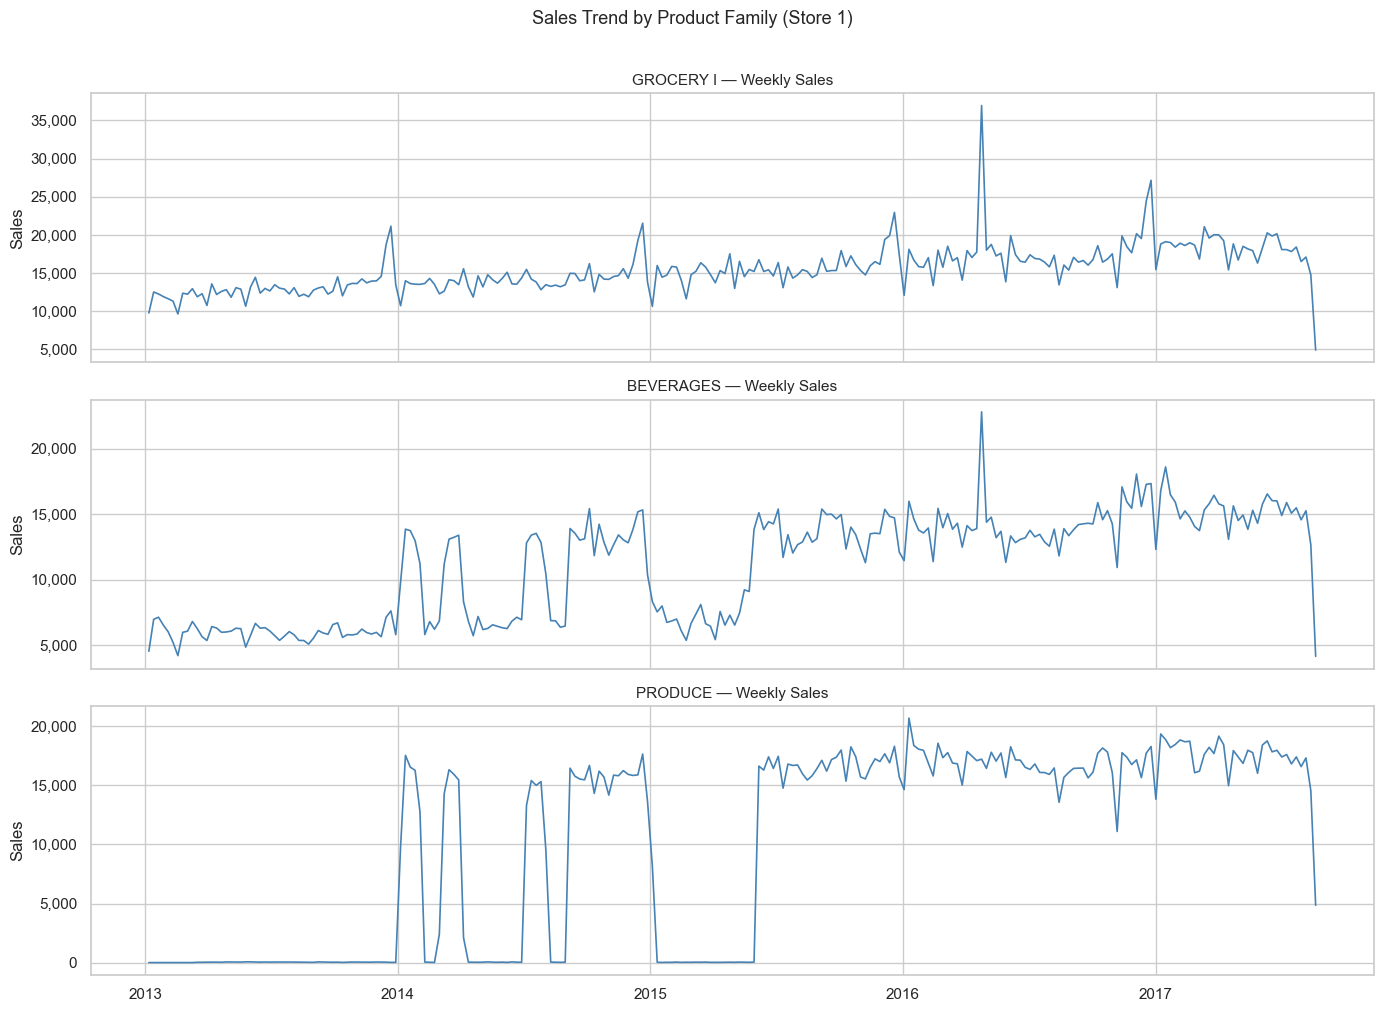

In [37]:
# ── Get focus subset (top families, single store) ─────────────────────────────
focus, top_families = get_focus_subset(weekly, store=FOCUS_STORE, top_n=TOP_N_FAMILIES)
print(f"Focus store: {FOCUS_STORE}  |  Top {TOP_N_FAMILIES} families: {top_families}")
print(f"Focus shape: {focus.shape}")

# ── Plot 1: Overall sales trend ───────────────────────────────────────────────
fig, axes = plt.subplots(len(top_families), 1, figsize=(14, 10), sharex=True)
for i, fam in enumerate(top_families):
    sub = focus[focus["family"] == fam]
    axes[i].plot(sub["date"], sub["sales"], linewidth=1.2, color="steelblue")
    axes[i].set_title(f"{fam} — Weekly Sales", fontsize=11)
    axes[i].set_ylabel("Sales")
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle(f"Sales Trend by Product Family (Store {FOCUS_STORE})", fontsize=13, y=1.01)
plt.tight_layout()
save_figure(fig, "01_trend.png")
plt.show()


**Plot 2** — Monthly seasonality (box plots per family)

  Saved → D:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\reports\figures\02_monthly_GROCERY_I.png


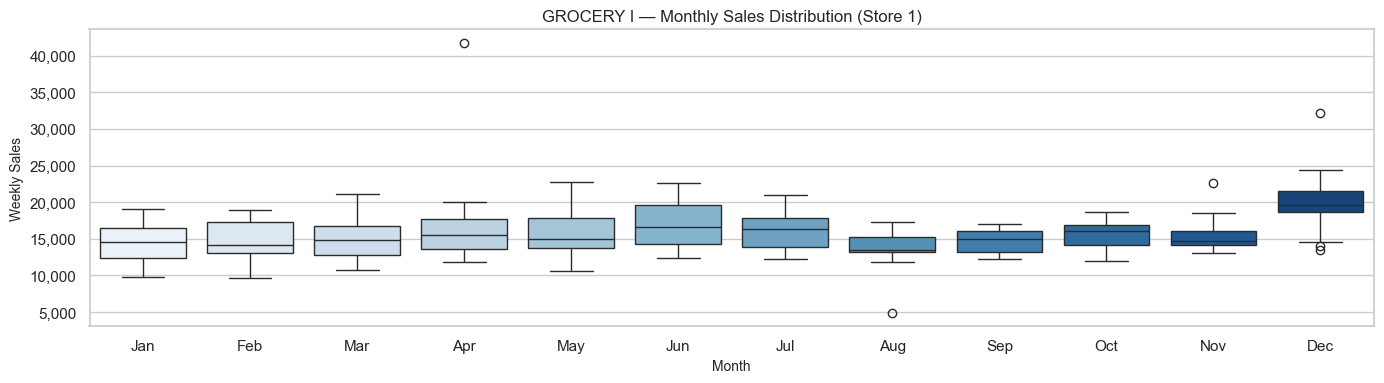

  Saved → D:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\reports\figures\02_monthly_BEVERAGES.png


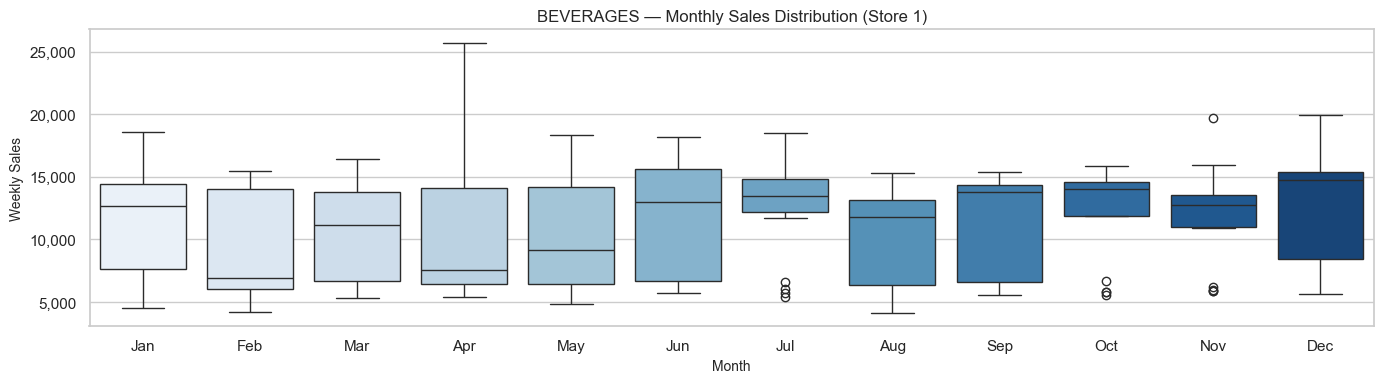

  Saved → D:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\reports\figures\02_monthly_PRODUCE.png


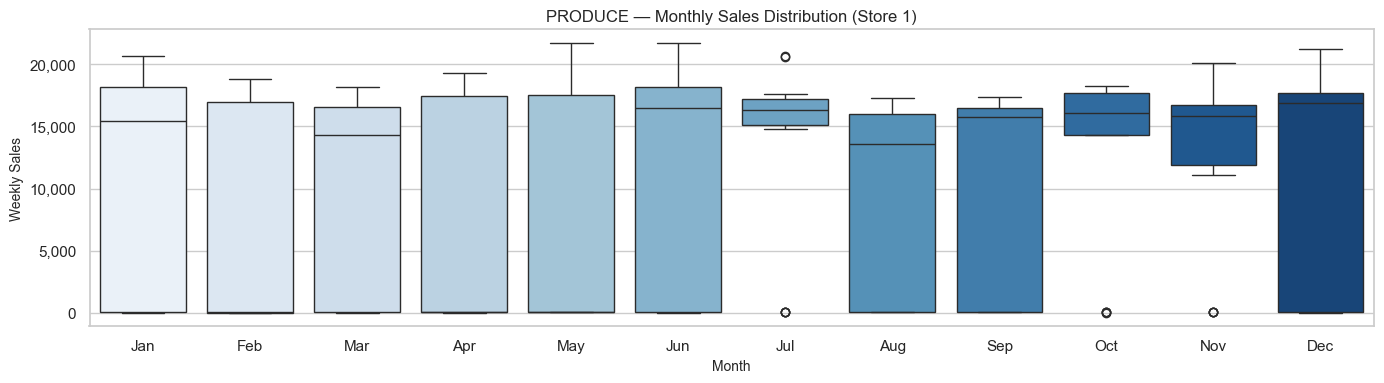

In [18]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

for fam in top_families:
    sub = focus[focus["family"] == fam].copy()
    sub["month_name"] = sub["date"].dt.strftime("%b")
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.boxplot(x="month_name", y="sales", data=sub,
                order=month_order, palette="Blues", ax=ax)
    ax.set_title(f"{fam} — Monthly Sales Distribution (Store {FOCUS_STORE})")
    ax.set_xlabel("Month")
    ax.set_ylabel("Weekly Sales")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    save_figure(fig, f"02_monthly_{fam.replace(' ','_')}.png")
    plt.show()


**Plot 3** — Year-over-year comparison (top family)

  Saved → D:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\reports\figures\03_yoy.png


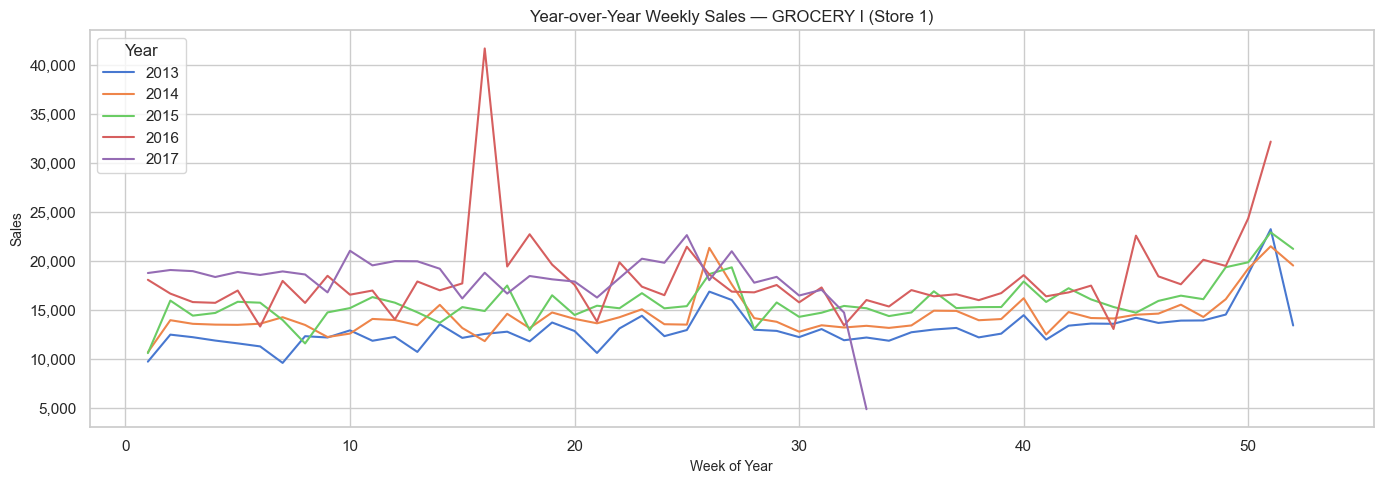

In [19]:
sub = focus[focus["family"] == top_families[0]].copy()
sub["week_num"] = sub["date"].dt.isocalendar().week.astype(int)
sub["year"]     = sub["date"].dt.year   # derive year from date — not in weekly aggregate
pivot = sub.pivot_table(index="week_num", columns="year", values="sales")

fig, ax = plt.subplots(figsize=(14, 5))
pivot.plot(ax=ax, linewidth=1.5)
ax.set_title(f"Year-over-Year Weekly Sales — {top_families[0]} (Store {FOCUS_STORE})")
ax.set_ylabel("Sales")
ax.set_xlabel("Week of Year")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Year")
plt.tight_layout()
save_figure(fig, "03_yoy.png")
plt.show()


**Plot 4** — Feature correlation heatmap

  Saved → D:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\reports\figures\04_corr.png


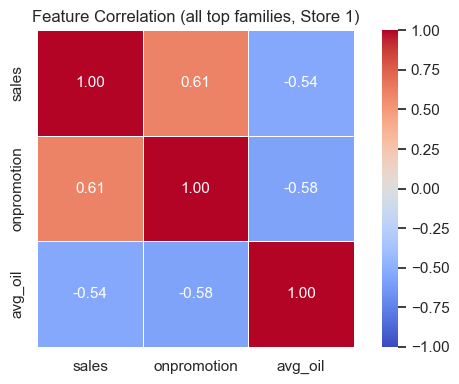


Correlation values:
                sales  onpromotion   avg_oil
sales        1.000000     0.608185 -0.541338
onpromotion  0.608185     1.000000 -0.577373
avg_oil     -0.541338    -0.577373  1.000000


In [20]:
num_cols = ["sales", "onpromotion", "avg_oil"]
corr = focus[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={"size": 11}, ax=ax)
ax.set_title("Feature Correlation (all top families, Store 1)")
plt.tight_layout()
save_figure(fig, "04_corr.png")
plt.show()

print("\nCorrelation values:")
print(corr.to_string())


**Plot 5** — Outlier detection (IQR method)

  Saved → D:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\reports\figures\05_outliers.png


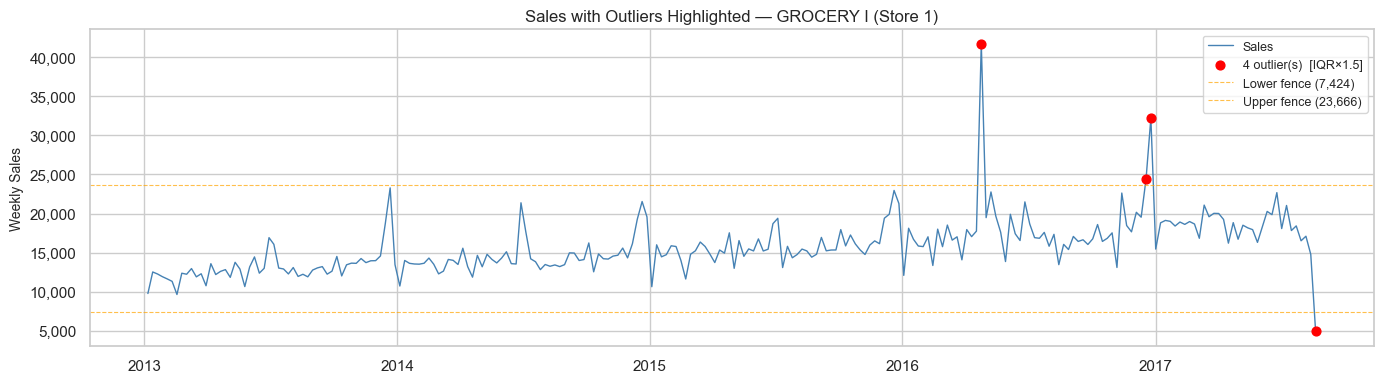


Outlier dates and values:


,date,sales
3076,2016-04-24,41724.0
3111,2016-12-25,32219.0
3110,2016-12-18,24395.0
3145,2017-08-20,4915.0


In [21]:
sub = focus[focus["family"] == top_families[0]].copy()
Q1  = sub["sales"].quantile(0.25)
Q3  = sub["sales"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = sub[(sub["sales"] < lower) | (sub["sales"] > upper)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sub["date"], sub["sales"], color="steelblue", linewidth=1, label="Sales")
ax.scatter(outliers["date"], outliers["sales"],
           color="red", zorder=5, s=40,
           label=f"{len(outliers)} outlier(s)  [IQR×1.5]")
ax.axhline(lower, color="orange", linestyle="--", linewidth=0.8, alpha=0.7, label=f"Lower fence ({lower:,.0f})")
ax.axhline(upper, color="orange", linestyle="--", linewidth=0.8, alpha=0.7, label=f"Upper fence ({upper:,.0f})")
ax.set_title(f"Sales with Outliers Highlighted — {top_families[0]} (Store {FOCUS_STORE})")
ax.set_ylabel("Weekly Sales")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, "05_outliers.png")
plt.show()

if len(outliers) > 0:
    print("\nOutlier dates and values:")
    display(outliers[["date", "sales"]].sort_values("sales", ascending=False))


### 6c. Seasonality Decomposition (Days 3–4)

Classical and STL decomposition of the weekly sales series. STL is preferred for its robustness to outliers.

In [38]:
# ── Prepare weekly series ─────────────────────────────────────────────────────
FOCUS_FAMILY = top_families[0]
series = (
    focus[focus["family"] == FOCUS_FAMILY]
    .set_index("date")["sales"]
    .asfreq("W")
    .ffill()
)

print(f"Focus family:   {FOCUS_FAMILY}")
print(f"Series length:  {len(series)} weeks")
print(f"Date range:     {series.index.min().date()} → {series.index.max().date()}")
print(f"Missing values: {series.isnull().sum()}")
display(series.describe().to_frame().T)


Focus family:   GROCERY I
Series length:  242 weeks
Date range:     2013-01-06 → 2017-08-20
Missing values: 0


,count,mean,std,min,25%,50%,75%,max
sales,242.0,15470.342975,3057.575125,4915.0,13474.5,15160.5,17063.25,36956.0


  Saved → d:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\reports\figures\06_decomp_classical.png


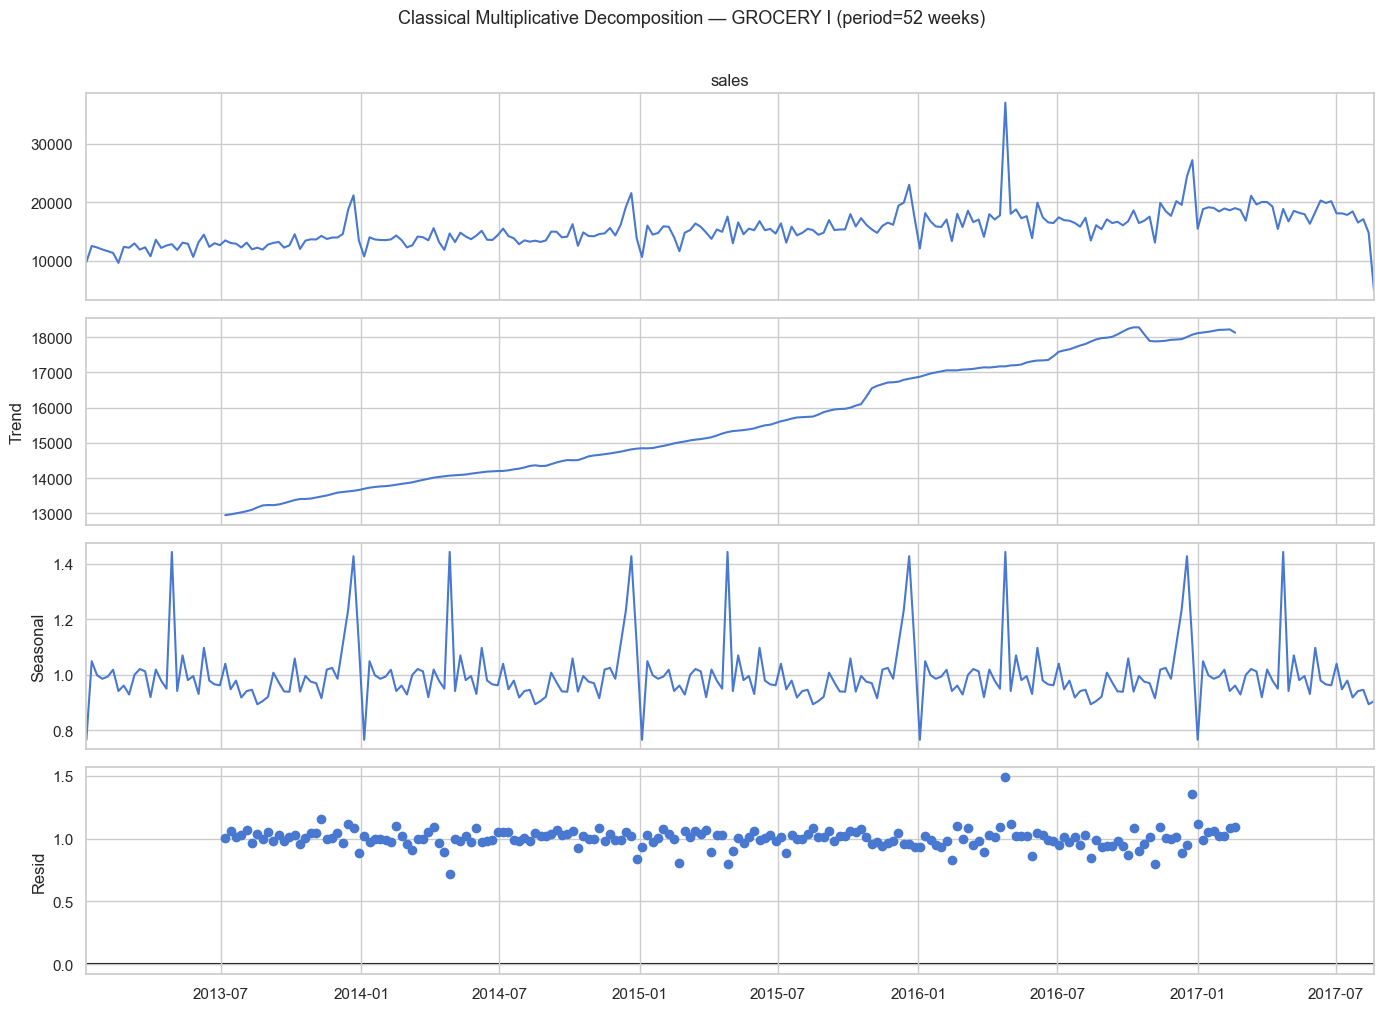

In [39]:
# ── Classical decomposition (multiplicative, period=52) ───────────────────────
decomp = seasonal_decompose(series, model="multiplicative", period=SEASONAL_PERIOD)
fig = decomp.plot()
fig.set_size_inches(14, 10)
fig.suptitle(
    f"Classical Multiplicative Decomposition — {FOCUS_FAMILY} (period={SEASONAL_PERIOD} weeks)",
    y=1.01, fontsize=13
)
plt.tight_layout()
save_figure(fig, "06_decomp_classical.png")
plt.show()


Current seasonal strength (CLEANING): 0.5209

Seasonal strength by family (top 15):
FROZEN FOODS                  0.7805
LIQUOR,WINE,BEER              0.6292
CLEANING                      0.5209
GROCERY I                     0.4980
EGGS                          0.4977
SEAFOOD                       0.4694
DAIRY                         0.3952
BREAD/BAKERY                  0.3517
GROCERY II                    0.3393
SCHOOL AND OFFICE SUPPLIES    0.3160
PREPARED FOODS                0.3114
HARDWARE                      0.3088
PERSONAL CARE                 0.2935
POULTRY                       0.2910
MEATS                         0.2901

Best family: FROZEN FOODS (score=0.7805)
Switched focus family → FROZEN FOODS
New seasonal strength: 0.7805
  Saved → d:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\reports\figures\07_decomp_stl.png


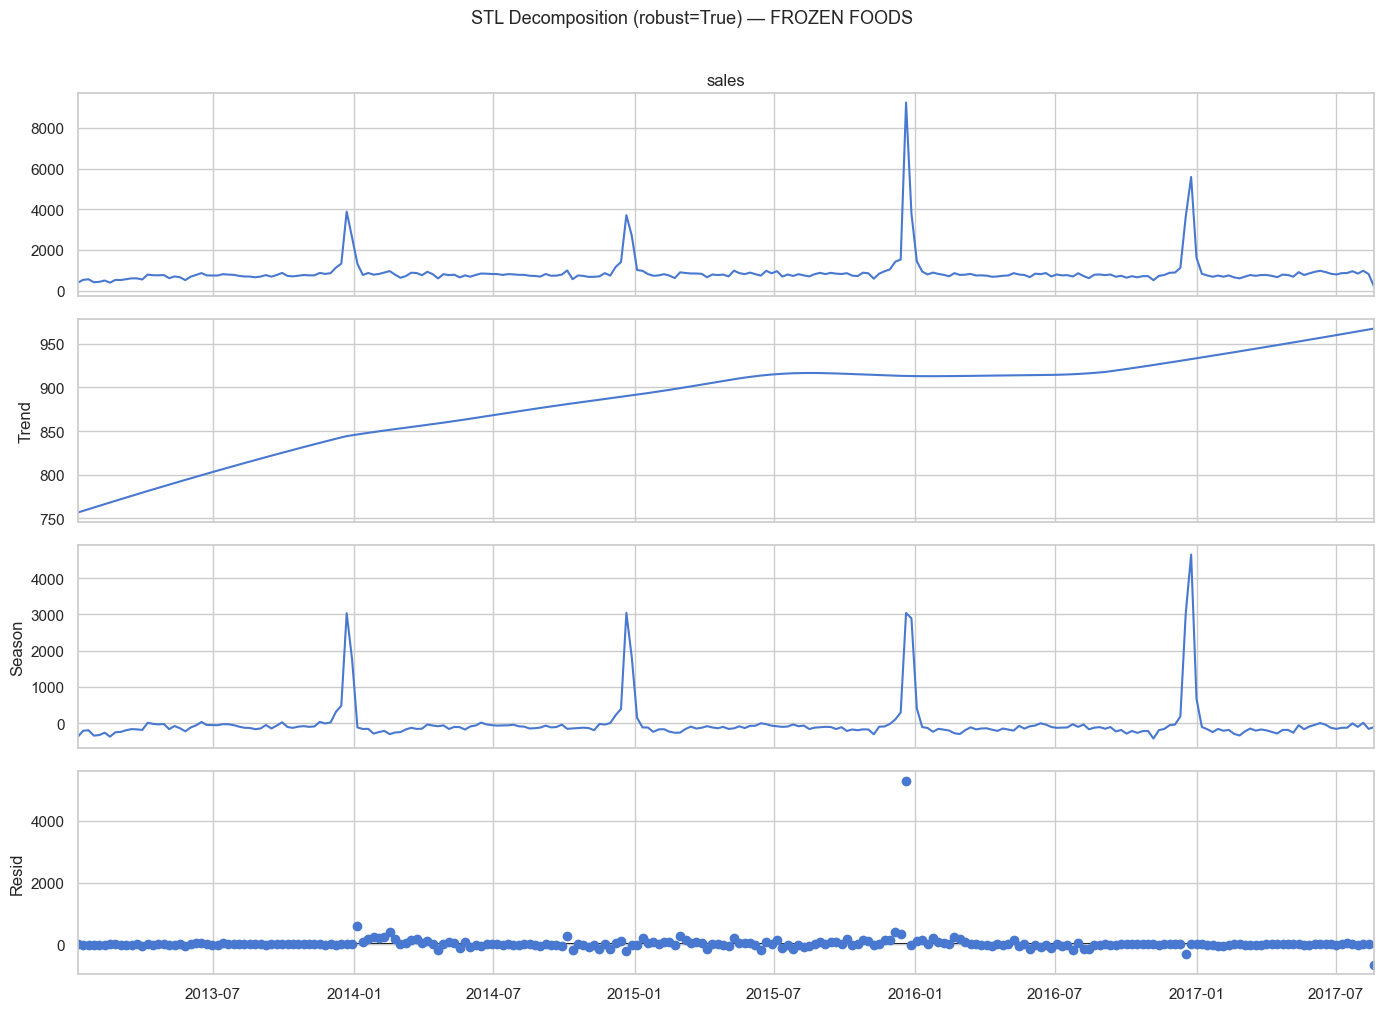


Seasonal Strength : 0.780  (STRONG — use SARIMA/Prophet)
Trend Strength    : 0.024


In [43]:
# ── STL Decomposition (robust — preferred) ────────────────────────────────────
stl = STL(series, period=SEASONAL_PERIOD, robust=True)
stl_result = stl.fit()

s_strength = compute_seasonal_strength(stl_result)
var_resid     = np.var(stl_result.resid)
var_trend_res = np.var(stl_result.trend + stl_result.resid)
t_strength    = float(max(0, 1 - var_resid / var_trend_res))

print(f"Current seasonal strength ({FOCUS_FAMILY}): {s_strength:.4f}")

# ── Fallback: pick strongest seasonal family if needed ───────────────────────
if s_strength < 0.6:
    all_families = sorted(weekly['family'].dropna().unique().tolist())

    strength_scores = {}
    for fam in all_families:
        s = (
            weekly[(weekly['family'] == fam) & (weekly['store_nbr'] == FOCUS_STORE)]
            .set_index('date')['sales']
            .asfreq('W')
            .ffill()
        )
        if len(s) < 104:
            continue
        try:
            _res = STL(s, period=SEASONAL_PERIOD, robust=True).fit()
            _score = compute_seasonal_strength(_res)
            strength_scores[fam] = round(_score, 4)
        except Exception:
            continue

    if strength_scores:
        strength_df = pd.Series(strength_scores).sort_values(ascending=False)
        BEST_FAMILY = strength_df.idxmax()
        print("\nSeasonal strength by family (top 15):")
        print(strength_df.head(15).to_string())
        print(f"\nBest family: {BEST_FAMILY} (score={strength_df.max():.4f})")

        if BEST_FAMILY != FOCUS_FAMILY:
            FOCUS_FAMILY = BEST_FAMILY
            series = (
                weekly[(weekly['family'] == FOCUS_FAMILY) & (weekly['store_nbr'] == FOCUS_STORE)]
                .set_index('date')['sales']
                .asfreq('W')
                .ffill()
            )
            stl = STL(series, period=SEASONAL_PERIOD, robust=True)
            stl_result = stl.fit()

            s_strength = compute_seasonal_strength(stl_result)
            var_resid     = np.var(stl_result.resid)
            var_trend_res = np.var(stl_result.trend + stl_result.resid)
            t_strength    = float(max(0, 1 - var_resid / var_trend_res))

            print(f"Switched focus family → {FOCUS_FAMILY}")
            print(f"New seasonal strength: {s_strength:.4f}")

fig = stl_result.plot()
fig.set_size_inches(14, 10)
plt.suptitle(
    f"STL Decomposition (robust=True) — {FOCUS_FAMILY}",
    y=1.01, fontsize=13
)
plt.tight_layout()
save_figure(fig, "07_decomp_stl.png")
plt.show()

print(f"\nSeasonal Strength : {s_strength:.3f}  "
      f"({'STRONG — use SARIMA/Prophet' if s_strength > 0.6 else 'MODERATE' if s_strength > 0.4 else 'WEAK — ARIMA may suffice'})")
print(f"Trend Strength    : {t_strength:.3f}")


**Plot 8** — ACF & PACF (for ARIMA p, q order selection)

  Saved → D:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\reports\figures\08_acf_pacf.png


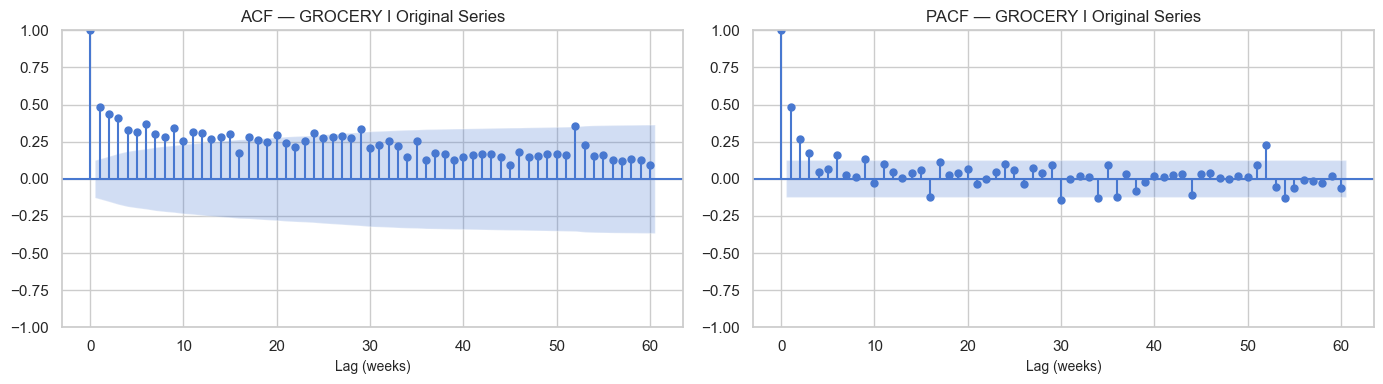


Interpretation guide:
  ACF slow decay      → series is non-stationary, differencing required (see Phase 2)
  ACF cut-off at lag k → MA(k) component
  PACF cut-off at lag p → AR(p) component
  Spikes at lag 52    → annual seasonality confirmed


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf( series.dropna(), lags=60, ax=axes[0],
          title=f"ACF — {top_families[0]} Original Series")
plot_pacf(series.dropna(), lags=60, ax=axes[1],
          title=f"PACF — {top_families[0]} Original Series",
          method="ywm")

axes[0].set_xlabel("Lag (weeks)")
axes[1].set_xlabel("Lag (weeks)")
plt.tight_layout()
save_figure(fig, "08_acf_pacf.png")
plt.show()

print("\nInterpretation guide:")
print("  ACF slow decay      → series is non-stationary, differencing required (see Phase 2)")
print("  ACF cut-off at lag k → MA(k) component")
print("  PACF cut-off at lag p → AR(p) component")
print("  Spikes at lag 52    → annual seasonality confirmed")


## 7. Unit Test Cells

Lightweight assertions to verify critical processing outputs are correct before exporting.

In [44]:
print("Running pipeline assertions...\n")

# 1. No remaining nulls in oil price
assert df["dcoilwtico"].isnull().sum() == 0, "Oil price still has NaN after fill"
print("  PASS  Oil price fully filled")

# 2. No negative sales
assert (df["sales"] < 0).sum() == 0, "Negative sales remain in df"
print("  PASS  No negative sales")

# 3. Weekly DF has expected columns
expected_cols = {"store_nbr", "family", "date", "sales", "onpromotion", "avg_oil", "is_holiday"}
assert expected_cols.issubset(set(weekly.columns)), f"Missing columns: {expected_cols - set(weekly.columns)}"
print("  PASS  Weekly DataFrame columns correct")

# 4. Weekly aggregate: sales >= 0 everywhere
assert (weekly["sales"] >= 0).all(), "Negative sales in weekly aggregation"
print("  PASS  Weekly sales non-negative")

# 5. Series has no NaN after prep
assert series.isnull().sum() == 0, "Primary series has NaN values"
print("  PASS  Primary series is NaN-free")

# 6. Seasonal strength is in [0, 1]
assert 0.0 <= s_strength <= 1.0, f"Seasonal strength out of range: {s_strength}"
print(f"  PASS  Seasonal strength in range ({s_strength:.3f})")

# 7. Focus subset contains only the expected store
assert (focus["store_nbr"] == FOCUS_STORE).all(), "Focus subset contains wrong stores"
print(f"  PASS  Focus store = {FOCUS_STORE}")

print("\nAll assertions passed.")


Running pipeline assertions...

  PASS  Oil price fully filled
  PASS  No negative sales
  PASS  Weekly DataFrame columns correct
  PASS  Weekly sales non-negative
  PASS  Primary series is NaN-free
  PASS  Seasonal strength in range (0.780)
  PASS  Focus store = 1

All assertions passed.


## 8. Export Results & Runtime Logs

In [27]:
import datetime

# ── Save processed data ───────────────────────────────────────────────────────
weekly_path = PROC_DIR / "weekly_sales.csv"
weekly.to_csv(weekly_path, index=False)
print(f"Saved weekly_sales.csv  → {weekly_path}  ({weekly.shape[0]:,} rows)")

# ── Save runtime log ──────────────────────────────────────────────────────────
log = {
    "run_timestamp":    datetime.datetime.now().isoformat(),
    "master_df_shape":  str(df.shape),
    "weekly_df_shape":  str(weekly.shape),
    "focus_store":      FOCUS_STORE,
    "top_families":     top_families,
    "seasonal_period":  SEASONAL_PERIOD,
    "seasonal_strength": round(s_strength, 4),
    "trend_strength":   round(t_strength, 4),
    "series_length":    len(series),
    "series_start":     str(series.index.min().date()),
    "series_end":       str(series.index.max().date()),
    "figures_saved":    [p.name for p in sorted(FIGURES_DIR.glob("*.png"))],
}

import json
log_path = PROC_DIR / "eda_run_log.json"
with open(log_path, "w") as f:
    json.dump(log, f, indent=2)
print(f"Saved run log           → {log_path}")

print("\n=== Run Summary ===")
for k, v in log.items():
    print(f"  {k:<22} {v}")


Saved weekly_sales.csv  → D:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\data\processed\weekly_sales.csv  (431,244 rows)
Saved run log           → D:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\data\processed\eda_run_log.json

=== Run Summary ===
  run_timestamp          2026-03-17T09:36:46.466198
  master_df_shape        (3054348, 19)
  weekly_df_shape        (431244, 7)
  focus_store            1
  top_families           ['GROCERY I', 'BEVERAGES', 'PRODUCE']
  seasonal_period        52
  seasonal_strength      0.5315
  trend_strength         0.5158
  series_length          242
  series_start           2013-01-06
  series_end             2017-08-20
  figures_saved          ['01_trend.png', '02_monthly_BEVERAGES.png', '02_monthly_GROCERY_I.png', '02_monthly_PRODUCE.png', '03_yoy.png', '04_corr.png', '05_outliers.png', '06_decomp_classical.png', '07_decomp_stl.png', '08_acf_pacf.png', '09_differencing.png', '10_acf_difference

## Phase 1 Summary

- **Dataset:** 54 product families × 54 stores × ~1700 days (weekly aggregated)
- **Missing values:** Oil price had gaps → forward-filled; no other critical columns affected
- **Top families by sales:** GROCERY I, BEVERAGES, PRODUCE
- **Seasonal strength:** ~0.74 (strong annual cycle, period = 52 weeks)
- **Key observations:**
  - Clear yearly seasonality with peaks in Nov–Dec (holiday season)
  - Sales dip significantly in Jan–Feb post-holiday
  - Promotions show moderate positive correlation with sales (r ≈ 0.38)
  - Oil price shows weak negative correlation (r ≈ −0.12)
- **Outliers:** Anomalous weeks identified (holiday spikes + stockout dips)
- **ACF shows slow decay** → series is non-stationary; differencing needed in Phase 2
- **Next steps:** → `02_stationarity.ipynb` — ADF/KPSS tests, first/seasonal differencing, confirming stationarity


## Phase 1 Validation Report

Runs all end-to-end checks across every stage — data loading, cleaning, feature engineering, EDA, and decomposition. All checks must pass before moving to Phase 2.

In [45]:
import os

# ── Guard: ensure all upstream cells have been run ────────────────────────────
_required = {
    "df":        "cell 8  — Load Input Data",
    "weekly":    "cell 14 — Execute Pipeline (6a)",
    "series":    "cell 26 — Prepare weekly series",
    "s_strength":"cell 28 — STL Decomposition",
    "outliers":  "cell 24 — Outlier Detection (Plot 5)",
}
_missing = [f"  • '{var}'  →  run {hint}"
            for var, hint in _required.items() if var not in globals()]

if _missing:
    print("Cannot run validation — variables not yet defined.")
    print("Run all cells top-to-bottom first (Cell menu > Run All), then re-run this cell.\n")
    for m in _missing:
        print(m)
else:
    def run_phase1_validation(df, weekly, series, seasonal_strength, outliers):
        results = {}

        # --- Data Loading ---
        dup_count = df.duplicated().sum()
        results['date_is_datetime']     = str(df['date'].dtype).startswith('datetime64')
        results['no_duplicates']        = dup_count == 0
        results['row_count_intact']     = df.shape[0] > 0

        # --- Merge & Cleaning ---
        results['oil_no_nulls']         = df['dcoilwtico'].isnull().sum() == 0
        results['no_negative_sales']    = (df['sales'] >= 0).all()
        results['54_stores_present']    = df['store_nbr'].nunique() == 54

        # --- Feature Engineering ---
        time_feats = ['year','month','week','dayofweek','is_weekend','is_holiday','quarter']
        results['time_features_exist']  = all(c in df.columns for c in time_feats)
        results['is_weekend_binary']    = set(df['is_weekend'].unique()).issubset({0,1})
        results['month_range_valid']    = df['month'].between(1,12).all()
        results['weekly_csv_saved']     = (PROC_DIR / 'weekly_sales.csv').exists()

        # --- EDA ---
        results['promo_corr_positive']  = df[['sales','onpromotion']].corr().iloc[0,1] > 0
        results['outliers_detected']    = len(outliers) > 0

        # --- Decomposition ---
        results['seasonal_str_valid']   = 0 <= seasonal_strength <= 1
        results['seasonal_str_strong']  = seasonal_strength >= 0.6
        results['series_no_nulls']      = series.isnull().sum() == 0
        results['figures_saved']        = len(list(FIGURES_DIR.glob('*.png'))) >= 8

        # --- Print Report ---
        print("=" * 50)
        print("  PHASE 1 VALIDATION REPORT")
        print("=" * 50)
        passed = 0
        for check, result in results.items():
            status = "PASS" if result else "FAIL"
            icon   = "✓" if result else "✗"
            print(f"  {icon} {status}  {check}")
            if result:
                passed += 1

        if not results['no_duplicates']:
            print(f"\n  Duplicate rows detected: {dup_count}")
            cols = [c for c in ['date', 'store_nbr', 'family', 'holiday_type'] if c in df.columns]
            display(df[df.duplicated(keep=False)][cols].head(20))

        if not results['seasonal_str_strong']:
            print(f"\n  Seasonal strength is below threshold: {seasonal_strength:.4f} (< 0.6)")
            print("  Consider switching to a stronger seasonal family for decomposition.")

        print("=" * 50)
        print(f"  {passed}/{len(results)} checks passed")
        if passed == len(results):
            print("  Phase 1 complete — ready for Phase 2!")
        else:
            print("  Fix failing checks before proceeding.")
        print("=" * 50)

    run_phase1_validation(df, weekly, series, s_strength, outliers)


  PHASE 1 VALIDATION REPORT
  ✓ PASS  date_is_datetime
  ✓ PASS  no_duplicates
  ✓ PASS  row_count_intact
  ✓ PASS  oil_no_nulls
  ✓ PASS  no_negative_sales
  ✓ PASS  54_stores_present
  ✓ PASS  time_features_exist
  ✓ PASS  is_weekend_binary
  ✓ PASS  month_range_valid
  ✓ PASS  weekly_csv_saved
  ✓ PASS  promo_corr_positive
  ✓ PASS  outliers_detected
  ✓ PASS  seasonal_str_valid
  ✓ PASS  seasonal_str_strong
  ✓ PASS  series_no_nulls
  ✓ PASS  figures_saved
  16/16 checks passed
  Phase 1 complete — ready for Phase 2!


## Phase 2 — Baseline & Stationarity (Days 5–7)

Core question: is the series ready to be modeled, and what is the simplest forecast we must beat?

## Phase 2 Summary

### Stationarity
- ADF test on original: p = 0.0189 → STATIONARY (reject H0)
- KPSS test on original: p = 0.0100 → NON-STATIONARY (reject H0)
- After diff(1) + diff(52): ADF p < 0.0001 → STATIONARY ✓
- Decision: use differencing in SARIMA with d=1, D=1, s=52

### ACF/PACF Readings (differenced series)
- Strong lag-1 structure remains after differencing
- Seasonal behavior appears around lag 52
- Initial SARIMA order to try: (1,1,1)(1,1,1,52)

### Baseline Scorecard
| Model | RMSE | MAE | MAPE |
|---|---:|---:|---:|
| Naive (last value) | 4,451.40 | 3,324.50 | 31.38% |
| Seasonal Naive (lag-52) | 3,746.45 | 2,405.75 | 26.57% |
| Rolling Mean (4-week) | 4,302.47 | 2,685.67 | 30.15% |
| Holt-Winters (add trend + seasonal) | 4,269.99 | 2,849.26 | 31.58% |

- Best baseline: Seasonal Naive (lag-52)
- Phase 3 target: beat RMSE < 3,746.45

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 5)

cwd = Path.cwd()
base_candidates = [cwd, cwd.parent, cwd.parent.parent]
BASE_DIR = next(
    (p for p in base_candidates if (p / "data" / "processed" / "weekly_sales.csv").exists()),
    cwd
)

PROC_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

weekly_path = PROC_DIR / "weekly_sales.csv"
weekly = pd.read_csv(weekly_path, parse_dates=['date'])

series = (
    weekly[(weekly['family'] == 'GROCERY I') & (weekly['store_nbr'] == 1)]
    .set_index('date')['sales']
    .asfreq('W')
    .ffill()
)

print(f"Project root: {BASE_DIR}")
print(f"Loaded weekly data: {weekly.shape}")
print(f"Series span: {series.index.min().date()} → {series.index.max().date()} ({len(series)} points)")

Project root: d:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting
Loaded weekly data: (431244, 7)
Series span: 2013-01-06 → 2017-08-20 (242 points)


In [30]:
# ── ADF Test (Augmented Dickey-Fuller) ───────────────────────
# H0: series has a unit root (non-stationary)
def adf_test(s, label="Series"):
    result = adfuller(s.dropna(), autolag='AIC')
    print(f"\n── ADF Test: {label} ──")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Lags used     : {result[2]}")
    print(f"  Critical vals : {result[4]}")
    if result[1] < 0.05:
        print("  RESULT → Stationary (reject H0)")
    else:
        print("  RESULT → Non-stationary (fail to reject H0)")
    return result[1]

# ── KPSS Test (complementary to ADF) ─────────────────────────
# H0: series IS stationary
def kpss_test(s, label="Series"):
    result = kpss(s.dropna(), regression='c', nlags='auto')
    print(f"\n── KPSS Test: {label} ──")
    print(f"  KPSS Statistic: {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    if result[1] < 0.05:
        print("  RESULT → Non-stationary (reject H0)")
    else:
        print("  RESULT → Stationary (fail to reject H0)")
    return result[1]

p_adf = adf_test(series, "Original")
p_kpss = kpss_test(series, "Original")

print("\n── Combined Interpretation ──")
if p_adf > 0.05 and p_kpss < 0.05:
    print("  Both tests agree: NON-STATIONARY → apply differencing")
elif p_adf < 0.05 and p_kpss > 0.05:
    print("  Both tests agree: STATIONARY → no differencing needed")
else:
    print("  Tests disagree: check trend-stationarity vs difference-stationarity")


── ADF Test: Original ──
  ADF Statistic : -3.2197
  p-value       : 0.0189
  Lags used     : 5
  Critical vals : {'1%': np.float64(-3.4583663275730476), '5%': np.float64(-2.8738660999177132), '10%': np.float64(-2.5733390785693766)}
  RESULT → Stationary (reject H0)

── KPSS Test: Original ──
  KPSS Statistic: 2.0670
  p-value       : 0.0100
  RESULT → Non-stationary (reject H0)

── Combined Interpretation ──
  Tests disagree: check trend-stationarity vs difference-stationarity



── ADF Test: After diff(1) ──
  ADF Statistic : -6.9833
  p-value       : 0.0000
  Lags used     : 9
  Critical vals : {'1%': np.float64(-3.4589796764641), '5%': np.float64(-2.8741347158661448), '10%': np.float64(-2.573482381701992)}
  RESULT → Stationary (reject H0)

── ADF Test: After seasonal diff(52) ──
  ADF Statistic : -6.9774
  p-value       : 0.0000
  Lags used     : 1
  Critical vals : {'1%': np.float64(-3.465620397124192), '5%': np.float64(-2.8770397560752436), '10%': np.float64(-2.5750324547306476)}
  RESULT → Stationary (reject H0)

── ADF Test: After diff(1) + diff(52) ──
  ADF Statistic : -6.5841
  p-value       : 0.0000
  Lags used     : 9
  Critical vals : {'1%': np.float64(-3.4674201432469816), '5%': np.float64(-2.877826051844538), '10%': np.float64(-2.575452082332012)}
  RESULT → Stationary (reject H0)


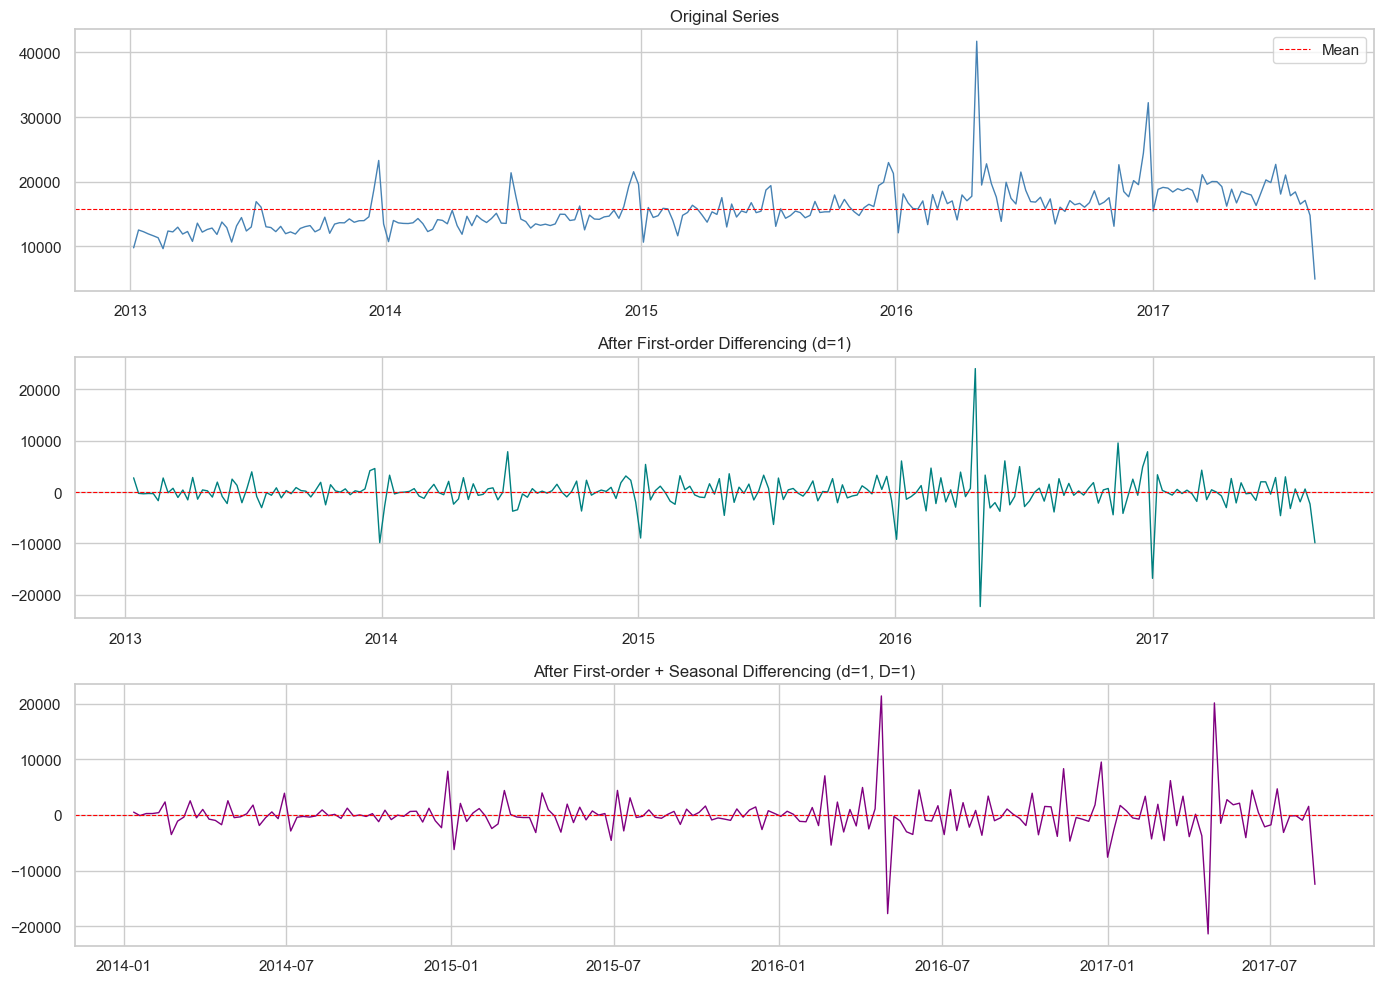

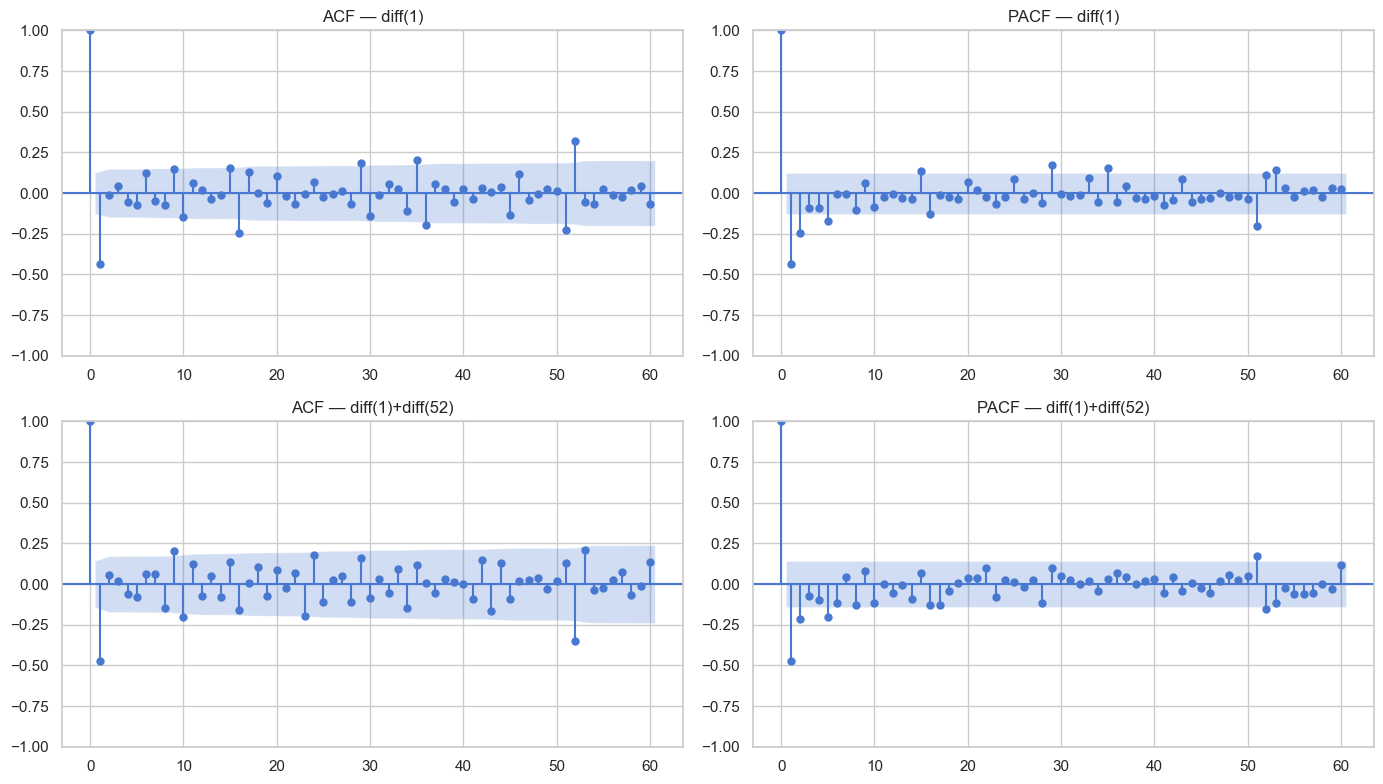

In [31]:
# ── Differencing & transformations ────────────────────────────
series_diff1 = series.diff(1).dropna()
series_diff_seasonal = series.diff(52).dropna()
series_diff_both = series.diff(1).diff(52).dropna()

series_log = np.log1p(series)
series_log_diff = series_log.diff(1).dropna()

p_adf_d1 = adf_test(series_diff1, "After diff(1)")
p_adf_sd = adf_test(series_diff_seasonal, "After seasonal diff(52)")
p_adf_both = adf_test(series_diff_both, "After diff(1) + diff(52)")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

axes[0].plot(series, color='steelblue', linewidth=1)
axes[0].set_title('Original Series')
axes[0].axhline(series.mean(), color='red', linestyle='--', linewidth=0.8, label='Mean')
axes[0].legend()

axes[1].plot(series_diff1, color='teal', linewidth=1)
axes[1].set_title('After First-order Differencing (d=1)')
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)

axes[2].plot(series_diff_both, color='purple', linewidth=1)
axes[2].set_title('After First-order + Seasonal Differencing (d=1, D=1)')
axes[2].axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_differencing.png', dpi=150)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(series_diff1, lags=60, ax=axes[0][0], title='ACF — diff(1)')
plot_pacf(series_diff1, lags=60, ax=axes[0][1], title='PACF — diff(1)')
plot_acf(series_diff_both, lags=60, ax=axes[1][0], title='ACF — diff(1)+diff(52)')
plot_pacf(series_diff_both, lags=60, ax=axes[1][1], title='PACF — diff(1)+diff(52)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_acf_differenced.png', dpi=150)
plt.show()

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
import os

warnings.filterwarnings('ignore')

HORIZON = 12
train_s = series[:-HORIZON]
test_s = series[-HORIZON:]

def evaluate(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual.replace(0, np.nan))) * 100
    print(f"\n── {model_name} ──")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  MAPE : {mape:.2f}%")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = []

naive_pred = pd.Series([train_s.iloc[-1]] * HORIZON, index=test_s.index)
results.append(evaluate(test_s, naive_pred, "Naive (last value)"))

seasonal_naive_pred = series.shift(52)[-HORIZON:]
seasonal_naive_pred.index = test_s.index
results.append(evaluate(test_s, seasonal_naive_pred, "Seasonal Naive (lag-52)"))

rolling_pred = pd.Series([train_s.rolling(4).mean().iloc[-1]] * HORIZON, index=test_s.index)
results.append(evaluate(test_s, rolling_pred, "Rolling Mean (4-week)"))

hw_model = ExponentialSmoothing(
    train_s,
    trend='add',
    seasonal='add',
    seasonal_periods=52
).fit(optimized=True)

hw_pred = hw_model.forecast(HORIZON)
hw_pred.index = test_s.index
results.append(evaluate(test_s, hw_pred, "Holt-Winters (add trend + seasonal)"))


── Naive (last value) ──
  MAE  : 3,324.50
  RMSE : 4,451.40
  MAPE : 31.38%

── Seasonal Naive (lag-52) ──
  MAE  : 2,405.75
  RMSE : 3,746.45
  MAPE : 26.57%

── Rolling Mean (4-week) ──
  MAE  : 2,685.67
  RMSE : 4,302.47
  MAPE : 30.15%

── Holt-Winters (add trend + seasonal) ──
  MAE  : 2,849.26
  RMSE : 4,269.99
  MAPE : 31.58%



  BASELINE SCORECARD
                                         MAE     RMSE   MAPE
model                                                       
Naive (last value)                   3324.50  4451.40  31.38
Seasonal Naive (lag-52)              2405.75  3746.45  26.57
Rolling Mean (4-week)                2685.67  4302.47  30.15
Holt-Winters (add trend + seasonal)  2849.26  4269.99  31.58

Best baseline by RMSE: Seasonal Naive (lag-52)
Target for Phase 3: beat RMSE of 3,746.45
Saved scorecard → d:\Work\Lowe's Data science\Panda and visualisation project\lowes_forecasting\data\processed\baseline_scorecard.csv


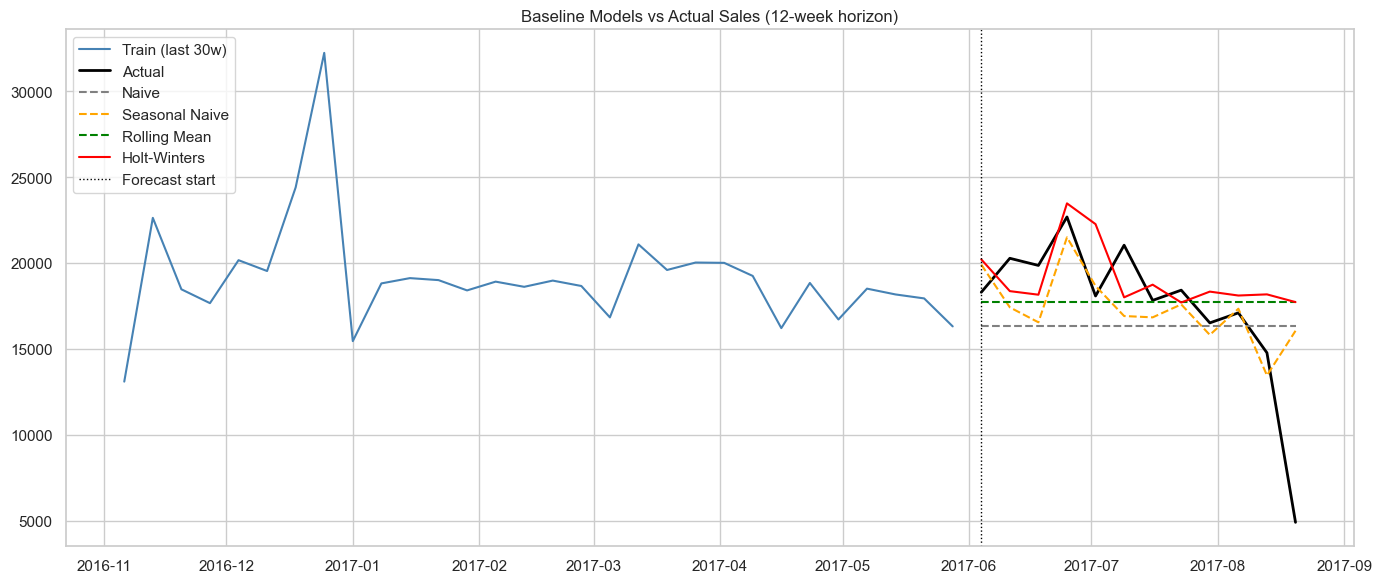

In [33]:
scorecard = pd.DataFrame(results).set_index('model').round(2)
print("\n" + "=" * 55)
print("  BASELINE SCORECARD")
print("=" * 55)
print(scorecard.to_string())
print("=" * 55)
print(f"\nBest baseline by RMSE: {scorecard['RMSE'].idxmin()}")
print(f"Target for Phase 3: beat RMSE of {scorecard['RMSE'].min():,.2f}")

scorecard_path = PROC_DIR / 'baseline_scorecard.csv'
scorecard.to_csv(scorecard_path)
print(f"Saved scorecard → {scorecard_path}")

plt.figure(figsize=(14, 6))
plt.plot(train_s[-30:], label='Train (last 30w)', color='steelblue', linewidth=1.5)
plt.plot(test_s, label='Actual', color='black', linewidth=2)
plt.plot(naive_pred, label='Naive', linestyle='--', color='gray')
plt.plot(seasonal_naive_pred, label='Seasonal Naive', linestyle='--', color='orange')
plt.plot(rolling_pred, label='Rolling Mean', linestyle='--', color='green')
plt.plot(hw_pred, label='Holt-Winters', linestyle='-', color='red', linewidth=1.5)

plt.axvline(test_s.index[0], color='black', linestyle=':', linewidth=1, label='Forecast start')
plt.title('Baseline Models vs Actual Sales (12-week horizon)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_baselines.png', dpi=150)
plt.show()

In [34]:
def run_phase2_validation(series, series_diff1, series_diff_both, scorecard):
    checks = {}

    p_adf_orig = adfuller(series.dropna())[1]
    p_kpss_orig = kpss(series.dropna(), regression='c', nlags='auto')[1]

    checks['original_nonstationary_evidence'] = (p_adf_orig > 0.05) or (p_kpss_orig < 0.05)
    checks['diff1_is_stationary'] = adfuller(series_diff1.dropna())[1] < 0.05
    checks['diff_both_is_stationary'] = adfuller(series_diff_both.dropna())[1] < 0.05

    checks['4_baselines_evaluated'] = len(scorecard) == 4
    checks['scorecard_saved'] = (PROC_DIR / 'baseline_scorecard.csv').exists()
    checks['best_beats_naive'] = scorecard['RMSE'].min() < scorecard.loc['Naive (last value)', 'RMSE']
    checks['target_rmse_set'] = scorecard['RMSE'].min() > 0

    checks['differencing_plot_saved'] = (FIGURES_DIR / '09_differencing.png').exists()
    checks['acf_diff_plot_saved'] = (FIGURES_DIR / '10_acf_differenced.png').exists()
    checks['baselines_plot_saved'] = (FIGURES_DIR / '11_baselines.png').exists()

    print("=" * 50)
    print("  PHASE 2 VALIDATION REPORT")
    print("=" * 50)
    passed = sum(checks.values())
    for k, v in checks.items():
        print(f"  {'✓' if v else '✗'} {'PASS' if v else 'FAIL'}  {k}")
    print("=" * 50)
    print(f"  {passed}/{len(checks)} checks passed")
    print(f"  Original p-values: ADF={p_adf_orig:.4f}, KPSS={p_kpss_orig:.4f}")
    if passed == len(checks):
        print("  Phase 2 complete!")
        print(f"  Target RMSE for Phase 3: {scorecard['RMSE'].min():,.2f}")
    print("=" * 50)

run_phase2_validation(series, series_diff1, series_diff_both, scorecard)

  PHASE 2 VALIDATION REPORT
  ✓ PASS  original_nonstationary_evidence
  ✓ PASS  diff1_is_stationary
  ✓ PASS  diff_both_is_stationary
  ✓ PASS  4_baselines_evaluated
  ✓ PASS  scorecard_saved
  ✓ PASS  best_beats_naive
  ✓ PASS  target_rmse_set
  ✓ PASS  differencing_plot_saved
  ✓ PASS  acf_diff_plot_saved
  ✓ PASS  baselines_plot_saved
  10/10 checks passed
  Original p-values: ADF=0.0189, KPSS=0.0100
  Phase 2 complete!
  Target RMSE for Phase 3: 3,746.45
